# Visualization Quality Metrics

This notebook computes **Trustworthiness**, **Continuity**, and **Shepard Diagrams** for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP) on a given benchmark dataset.

Embeddings and reduced embeddings are loaded from precomputed `.npy` files generated by `eval_pipeline.py`. See [INSTALL.md](../../INSTALL.md) for setup instructions.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances

# navigate to src/ from wherever the notebook is run
current = os.path.abspath('.')
while os.path.basename(current) != 'src' and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = current
os.chdir(src_dir)
sys.path.insert(0, src_dir)

In [2]:
# config: change dataset and embedding model here
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
dataset = "rcv1"  # options: rcv1, arxiv, amazon, dbpedia, wos

embedding_dir = f"{embedding_model}_embeddings"
reduction_dir = f"{embedding_model}_reduced_embeddings"
results_dir = f"{embedding_model}_results"
os.makedirs(results_dir, exist_ok=True)

## 1. Setup

Change `dataset` to run on a different benchmark. Available options: `rcv1`, `arxiv`, `amazon`, `dbpedia`, `wos`.

In [3]:
# load precomputed high-dimensional embeddings
x_high = np.load(f"{embedding_dir}/{dataset}.npy")
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (1566, 384)


## 2. Load Embeddings

Load precomputed embeddings from `eval_pipeline.py` output. To generate these, run:
```bash
python src/run_models/benchmark_datasets/eval_pipeline.py --dataset rcv1
```

In [4]:
# load precomputed reduced embeddings from eval_pipeline.py
reductions = {
    "PCA":    np.load(f"{reduction_dir}/PCA_{dataset}.npy"),
    "UMAP":   np.load(f"{reduction_dir}/UMAP_{dataset}.npy"),
    "PHATE":  np.load(f"{reduction_dir}/PHATE_{dataset}.npy"),
    "PaCMAP": np.load(f"{reduction_dir}/PaCMAP_{dataset}.npy"),
}

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

PCA: (1566, 300)
UMAP: (1566, 300)
PHATE: (1566, 300)
PaCMAP: (1566, 100)


In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]
    
    d_high = pairwise_distances(x_high)
    d_low = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)
    
    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors
    
    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

## 3. Trustworthiness & Continuity

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)

Both scores range from 0 to 1, higher is better.

In [6]:
stats = []

# subsample for large datasets to avoid memory issues (pairwise distances scale as n^2)
max_samples = 5000
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[idx]
    reductions_sub = {name: arr[idx] for name, arr in reductions.items()}
    print(f"Subsampled to {max_samples} points for metrics computation")
else:
    x_high_sub = x_high
    reductions_sub = reductions

for name, x_low in reductions_sub.items():
    # use first 2 dimensions for metrics (methods have varying n_components)
    x_low_2d = x_low[:, :2] if x_low.ndim > 1 and x_low.shape[1] > 2 else x_low

    t_score = trustworthiness(x_high_sub, x_low_2d, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_2d, n_neighbors=15)

    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4)
    })
    print(f"{name}: Trustworthiness={t_score:.4f}, Continuity={c_score:.4f}")

pd.DataFrame(stats)

PCA: Trustworthiness=0.5010, Continuity=0.5071
UMAP: Trustworthiness=0.5039, Continuity=0.5077
PHATE: Trustworthiness=0.5010, Continuity=0.5046
PaCMAP: Trustworthiness=0.5021, Continuity=0.5038


,Method,Trustworthiness,Continuity
0,PCA,0.5010,0.5071
1,UMAP,0.5039,0.5077
2,PHATE,0.5010,0.5046
3,PaCMAP,0.5021,0.5038


In [7]:
output_path = os.path.join(results_dir, f"viz_metrics_{dataset}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to sentence-transformers/all-MiniLM-L6-v2_results/viz_metrics_rcv1.csv


## 4. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

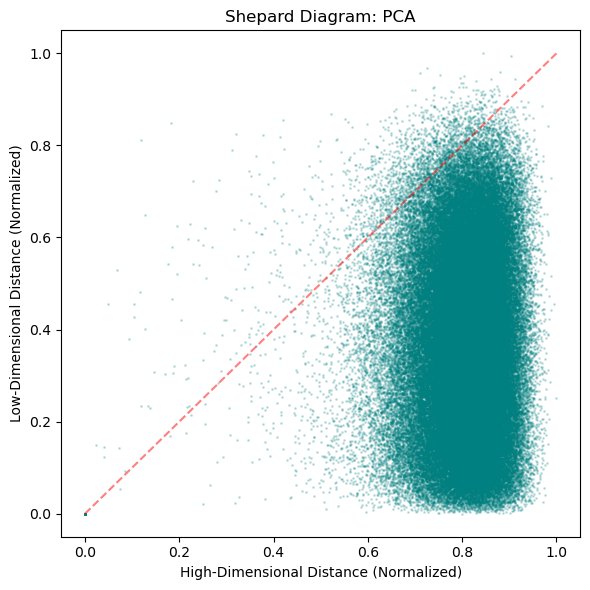

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_pca.png


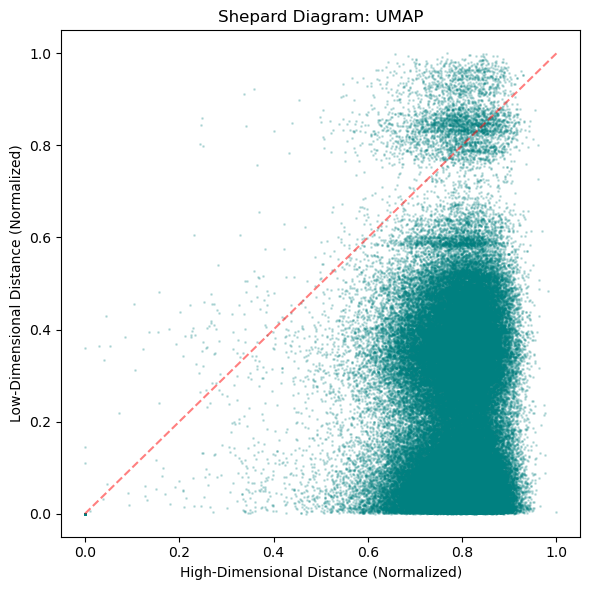

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_umap.png


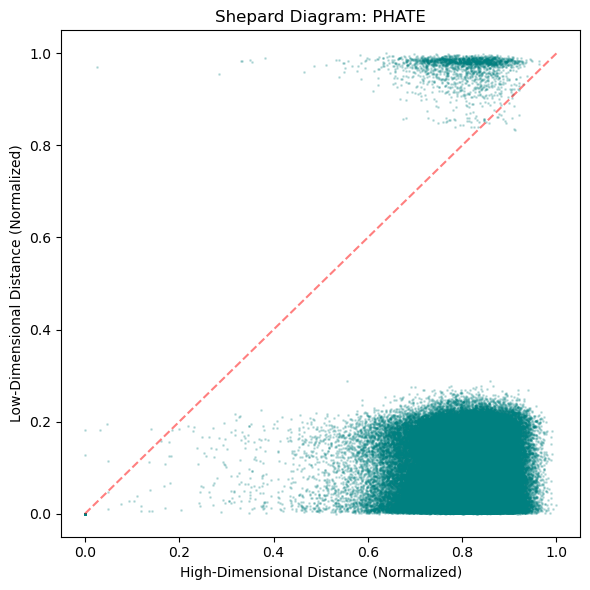

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_phate.png


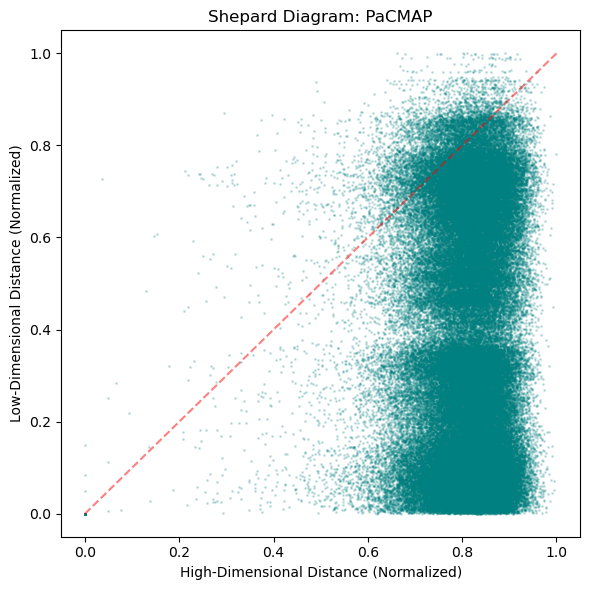

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_pacmap.png


In [8]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), sample_size, replace=False)
    
    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low = d_low / np.max(d_low)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()
    
    filename = os.path.join(results_dir, f"shepard_{dataset}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low in reductions.items():
    x_low_2d = x_low[:, :2] if x_low.ndim > 1 and x_low.shape[1] > 2 else x_low
    f = plot_shepard(x_high, x_low_2d, name)
    print(f"Saved: {f}")